# NorESM Updraft-Stratified CCN-CDNC Susceptibility

**Scientific question:** Does CCN-CDNC susceptibility depend on **updraft strength**? Stronger updrafts (higher W_sub) drive higher supersaturation and more activation, so susceptibility may be enhanced in the high-updraft tail. Here susceptibility is computed separately for updraft quartile bins (Q0-Q75, Q75-Q90, Q90-Q100, and Total) per station.

Updraft = NorESM `WSUB` (a floor-clipped transform of WP2_CLUBB), masked to in-cloud points (`FREQL > 0.8`). Susceptibility uses the shared `build_susceptibility_dataset_by_station` with `updraft_ds` supplied.

---
*Sections: 1 Setup · 2 Build CCN + updraft · 3 Stratified susceptibility · 4 Quartile plots · 5 Enhancement · 6 Save.*

## 1 · Setup and configuration

In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
NOR_PATH  = "/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"
SAVE_PATH = None   # e.g. "/share/pech2273/NorESM_Susceptibility_Updraft.nc" to save reg_ds

RADII    = np.logspace(np.log10(1), np.log10(500), 41)           # CCN cutoff radii [nm]
VAR_LIST = ['FREQL', 'WSUB', 'Z3']     # cloud frac, subgrid updraft, height
D_GRID   = xr.DataArray(np.logspace(-0.5, 3, num=200), dims=['D'],
                        coords={'D': np.logspace(-0.5, 3, num=200)})
CLOUD_FRAC_THRESHOLD = 0.8             # in-cloud mask

## 2 · Build CCN/CDNC and the cloud-masked updraft

Per station: integrate CCN per radius, cloud-mask CDNC at `FREQL > 0.8`, and stack. `Updraft` is WSUB, later masked by the same cloud threshold before stratification.

In [3]:
def CCN_CDNC_Dataset(CCN_ds, CDNC_da):
    """Align and package CCN (radius, lev, time) with CDNC (lev, time)."""
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)
    return xr.Dataset(
        data_vars={'CCN': CCN_aligned, 'CDNC': CDNC_aligned},
        coords={'radius': CCN_aligned.radius, 'lev': CCN_aligned.lev, 'time': CCN_aligned.time},
    )

In [4]:
ds = xr.open_dataset(NOR_PATH, chunks={})
stations = ds['station'].values

all_stationsCCN = []
for station in stations:
    Nor_ds = Function.NorESMExtract_Dask(NOR_PATH, station, VAR_LIST, D_GRID, PNSD=False)
    CCN_ds = Function.NorERF(Nor_ds, RADII)
    masked = CCN_CDNC_Dataset(CCN_ds, Nor_ds['CDNC'].where(Nor_ds['FREQL'] > CLOUD_FRAC_THRESHOLD))
    all_stationsCCN.append(masked.assign_coords(station=station))

CCN_all = xr.concat(all_stationsCCN, dim='station').compute()
Updraft = ds['WSUB']                                  # subgrid updraft (m/s)

/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


## 3 · Updraft-stratified susceptibility

Mask the updraft to in-cloud points, then call the shared builder with `updraft_ds` supplied — this stratifies the log-median binned fit into the four updraft_q bins.

In [5]:
Updraft_masked = Updraft.where(ds['FREQL'] > CLOUD_FRAC_THRESHOLD)

reg_ds = Function.build_susceptibility_dataset_by_station(
    ccn_all_ds = CCN_all,
    radii      = CCN_all.radius.values,
    updraft_ds = Updraft_masked,
    min_bin_points = 1,
    Binning    = 'Equal Number',
    output_name= 'OsloAero_station_updraft_susceptibility',
)
print(reg_ds)

Processing station: ZEP (1/15)
Processing station: SMR-II (2/15)
Processing station: ATTO (3/15)
Processing station: MHD (4/15)
Processing station: SGP (5/15)
Processing station: CHC (6/15)
Processing station: BIR-II (7/15)
Processing station: PAL (8/15)
Processing station: Vavihill (9/15)
Processing station: JFJ (10/15)
Processing station: FKL (11/15)
Processing station: SMEAR-I (12/15)
Processing station: Villum (13/15)
Processing station: Izana (14/15)
Processing station: Maldives (15/15)
<xarray.Dataset> Size: 80kB
Dimensions:    (station: 15, radius: 41, updraft_q: 4)
Coordinates:
  * station    (station) <U8 480B 'ZEP' 'SMR-II' 'ATTO' ... 'Izana' 'Maldives'
  * radius     (radius) float64 328B 1.0 1.168 1.364 1.594 ... 366.5 428.1 500.0
  * updraft_q  (updraft_q) <U7 112B '<=0.2' '0.2-0.5' '>0.5' 'Total'
Data variables:
    slope      (station, radius, updraft_q) float64 20kB 0.5621 0.7704 ... 0.331
    r_value    (station, radius, updraft_q) float64 20kB 0.9772 ... 0.5708
    st

## 4 · Susceptibility by updraft quartile

Across-station mean susceptibility (and correlation) vs particle diameter, one curve per updraft quartile. If high-updraft bins sit above Total, susceptibility is updraft-enhanced.

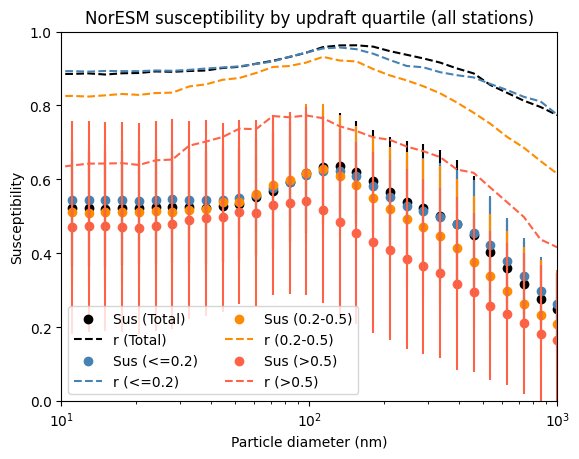

In [6]:
colors = {'Total': 'black', '<=0.2': 'steelblue',
          '0.2-0.5': 'darkorange', '>0.5': 'tomato'}

for q_label, color in colors.items():
    m = reg_ds['slope'].sel(updraft_q=q_label).mean('station')
    s = reg_ds['slope'].sel(updraft_q=q_label).std('station')
    plt.scatter(reg_ds['radius'] * 2, m, label=f'Sus ({q_label})', c=color)
    plt.errorbar(reg_ds['radius'] * 2, m, s, fmt='none', ecolor=color)
    plt.plot(reg_ds['radius'] * 2, reg_ds['r_value'].sel(updraft_q=q_label).mean('station'),
             label=f'r ({q_label})', c=color, ls='--')

plt.xscale('log'); plt.ylim([0, 1]); plt.xlim([10, 1000])
plt.xlabel('Particle diameter (nm)'); plt.ylabel('Susceptibility')
plt.title('NorESM susceptibility by updraft quartile (all stations)')
plt.legend(ncol=2); plt.show()

### 4a · Per-station hexbin by updraft (single radius)

Detailed view for one station/radius: CCN-CDNC hexbin coloured by W_sub, with the fitted susceptibility line per quartile. Call `updraft_susceptibility_graph(radius, station)`.

In [7]:
def updraft_susceptibility_graph(radius, station):
    """
    Four-panel CCN-CDNC hexbin (coloured by W_sub) for one station/radius:
    Total plus the three fixed updraft bins, each with its fitted susceptibility
    line from reg_ds. Bins match build_susceptibility_dataset_by_station:
    <=0.2 / 0.2-0.5 / >0.5 (half-open, fixed physical edges).
    """
    r = radius
    wsub = Updraft_masked.sel(station=station)
    log_x = np.log10(CCN_all['CCN'].isel(radius=r).sel(station=station)
                     .where(CCN_all['CDNC'].sel(station=station) > 0))
    log_y = np.log10(CCN_all['CDNC'].sel(station=station))

    Graphmin = float(np.nanmin([log_x.min().values, log_y.min().values]))
    Graphmax = float(np.nanmax([log_x.max().values, log_y.max().values]))
    plotline = np.linspace(Graphmin, Graphmax, 20)

    # --- Fixed physical updraft bins (match the susceptibility function) ---
    FLOOR = 0.2001
    bin_labels = ['<=0.2', '0.2-0.5', '>0.5']
    bin_colors = ['steelblue', 'seagreen', 'darkorange']

    def bin_mask(w, label):
        if label == '<=0.2':
            return w <= FLOOR
        elif label == '0.2-0.5':
            return (w > FLOOR) & (w <= 0.5)
        else:  # '>0.5'
            return w > 0.5

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    axes = axes.flatten()

    vmin = float(np.nanquantile(wsub, 0.05))
    vmax = float(np.nanquantile(wsub, 0.95))
    hb_ref = None

    # ---------- PANEL 0: TOTAL ----------
    ax = axes[0]
    valid = np.isfinite(log_x.values) & np.isfinite(log_y.values) & np.isfinite(wsub.values)
    lx, ly, w = log_x.values[valid], log_y.values[valid], wsub.values[valid]
    n_points = len(lx)

    hb = ax.hexbin(lx, ly, C=w, reduce_C_function=np.mean, cmap='viridis',
                   gridsize=[30, 30], vmin=vmin, vmax=vmax, mincnt=1,
                   edgecolors='none', extent=[Graphmin, Graphmax, Graphmin, Graphmax])
    hb_ref = hb

    slope = reg_ds.slope.isel(radius=r).sel(updraft_q='Total', station=station).values
    intercept = reg_ds.intercept.isel(radius=r).sel(updraft_q='Total', station=station).values
    if np.isfinite(slope):
        ax.plot(plotline, plotline * slope + intercept, color='black', lw=2, ls='--',
                label=f'slope={slope:.2f}')
    ax.plot([Graphmin, Graphmax], [Graphmin, Graphmax], 'r--')
    ax.set_title(f'Total (N={n_points})')
    ax.legend()

    # ---------- PANELS 1-3: FIXED UPDRAFT BINS ----------
    for i, (label, color) in enumerate(zip(bin_labels, bin_colors)):
        ax = axes[i + 1]
        mask = bin_mask(wsub, label).values
        lx = log_x.values[mask]
        ly = log_y.values[mask]
        w  = wsub.values[mask]
        valid = np.isfinite(lx) & np.isfinite(ly) & np.isfinite(w)
        lx, ly, w = lx[valid], ly[valid], w[valid]
        n_points = len(lx)

        if n_points >= 2:
            hb = ax.hexbin(lx, ly, C=w, reduce_C_function=np.mean, cmap='viridis',
                           gridsize=[30, 30], vmin=vmin, vmax=vmax, mincnt=1,
                           edgecolors='none', extent=[Graphmin, Graphmax, Graphmin, Graphmax])

            xmin, xmax = np.nanmin(lx), np.nanmax(lx)
            if np.isfinite(xmin) and np.isfinite(xmax) and xmin != xmax:
                Log_bins = np.linspace(xmin, xmax, 101)
                bin_idx = np.digitize(lx, Log_bins)
                lx_mean = np.array([lx[bin_idx == b].mean() if np.any(bin_idx == b) else np.nan
                                    for b in range(1, len(Log_bins))])
                ly_mean = np.array([ly[bin_idx == b].mean() if np.any(bin_idx == b) else np.nan
                                    for b in range(1, len(Log_bins))])
                vb = np.isfinite(lx_mean) & np.isfinite(ly_mean)
                ax.scatter(lx_mean[vb], ly_mean[vb], color=color, s=10, label='Bin means')

        # fitted line from reg_ds (NaN if the bin was under the 100-pt minimum)
        slope_ds = reg_ds.slope.isel(radius=r).sel(updraft_q=label, station=station).values
        intercept_ds = reg_ds.intercept.isel(radius=r).sel(updraft_q=label, station=station).values
        if np.isfinite(slope_ds):
            ax.plot(plotline, plotline * slope_ds + intercept_ds, color=color, ls='--',
                    label=f'Susceptibility = {slope_ds:.2f}')
        else:
            ax.plot([], [], ' ', label='Susceptibility = N/A (<100 pts)')

        ax.plot([Graphmin, Graphmax], [Graphmin, Graphmax], 'r--')
        ax.set_title(f'W$_{{sub}}$ {label} (N={n_points})')
        ax.legend(fontsize=7)

    # ---------- FORMAT ----------
    for ax in axes:
        ax.set_xlim([Graphmin, Graphmax]); ax.set_ylim([Graphmin, Graphmax])
        ax.set_xlabel('log$_{10}$(CCN)'); ax.set_ylabel('log$_{10}$(CDNC)')

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(hb_ref, cax=cbar_ax, label='Mean W$_{sub}$ (m/s)')
    plt.suptitle(f'{station} Susceptibility by Updraft (Dp = {reg_ds.radius[r]*2:.2f} nm)')
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

/tmp/ipykernel_1613028/704903612.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


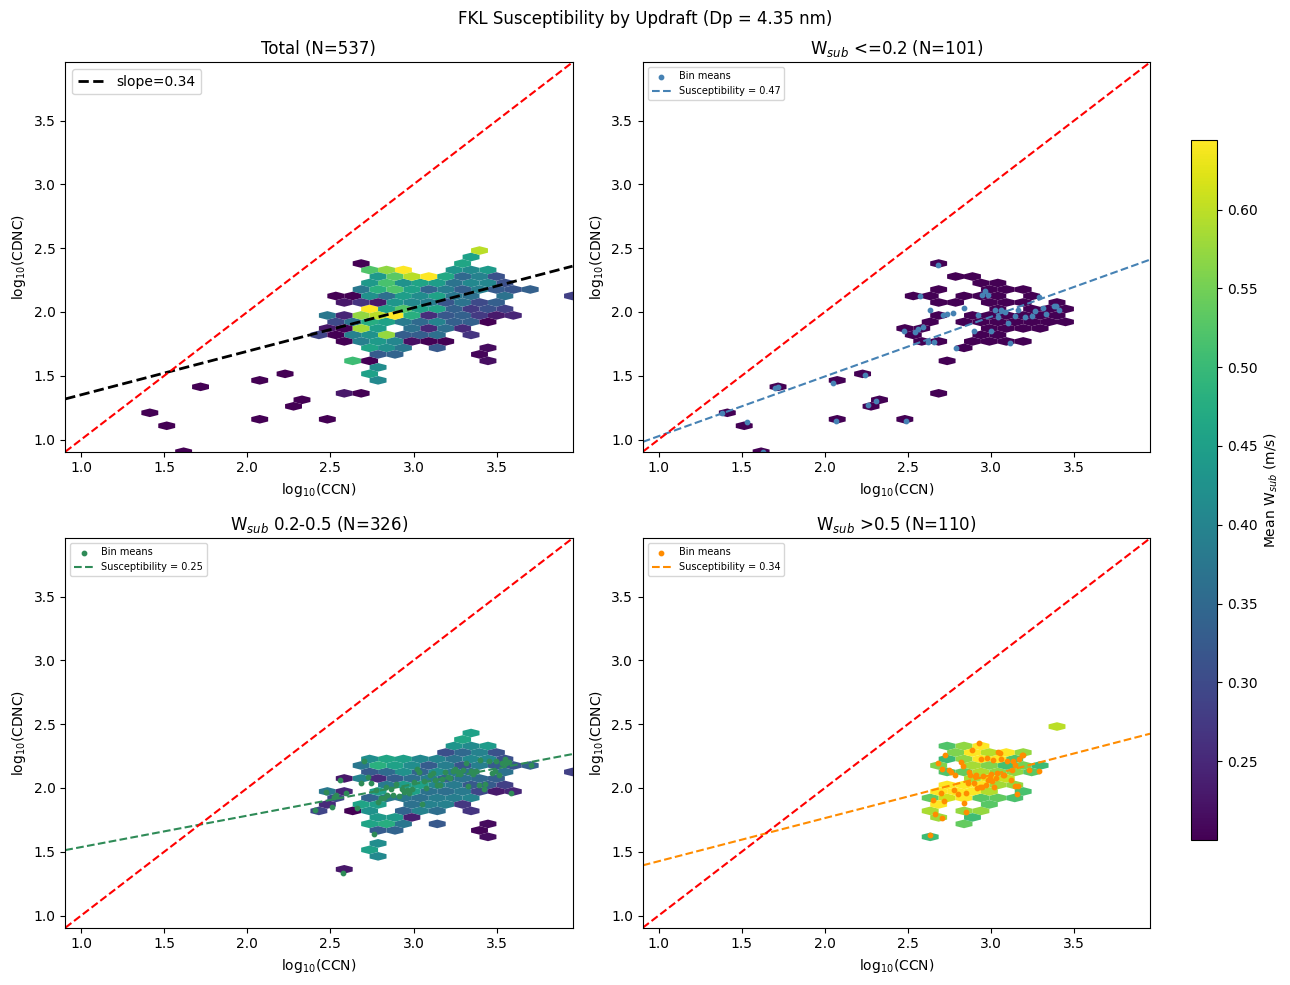

In [8]:
updraft_susceptibility_graph(radius=5, station='FKL')

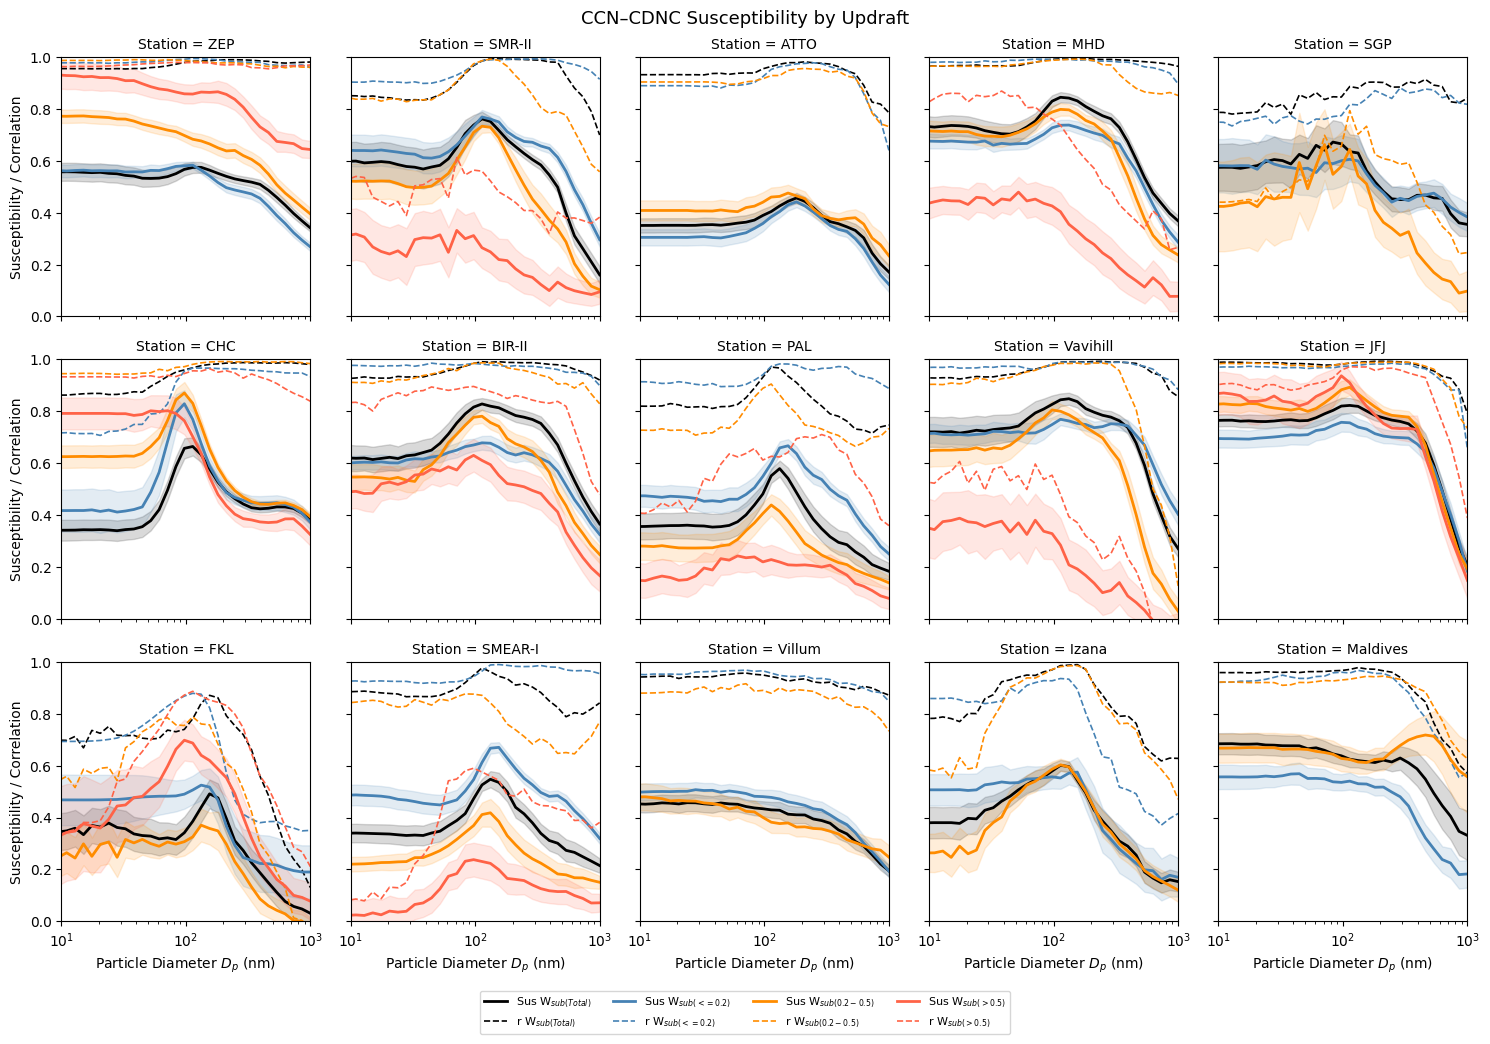

In [9]:
colors = {
    'Total':    'black',
    '<=0.2':   'steelblue',
    '0.2-0.5':  'darkorange',
    '>0.5': 'tomato',
}
stations = reg_ds.station.values


fig, axes = plt.subplots(3, 5, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, station in zip(axes, stations):
    for q_label, color in colors.items():
        ds = reg_ds.sel(updraft_q=q_label, station = station)

        ax.plot(ds['radius']*2, ds['slope'],
                color=color, linewidth=2,
                label=f'Sus W$_{{sub ({q_label})}}$')
        ax.fill_between(ds['radius']*2,
                        ds['slope'] - 1.98*ds['std_err'],
                        ds['slope'] + 1.98*ds['std_err'],
                        color=color, alpha=0.15)
        ax.plot(ds['radius']*2, ds['r_value'],
                '--', color=color, linewidth=1.2,
                label=f'r W$_{{sub ({q_label})}}$')

    ax.set_title(F'Station = {station}', fontsize=10)
    ax.set_ylim([0, 1])
    ax.set_xlim([10, 1000])
    ax.set_xscale('log')

# Shared axis labels
for ax in axes[10:]:  # bottom row
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')
for ax in axes[::5]:  # left column
    ax.set_ylabel('Susceptibility / Correlation')

# Single shared legend outside the subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', fontsize=8,
           ncols=len(colors), bbox_to_anchor=(0.5, -0.05))

fig.suptitle('CCN–CDNC Susceptibility by Updraft', fontsize=13)
plt.tight_layout()
plt.show()

## 5 · Susceptibility enhancement in high updraft

Percentage enhancement of the top updraft decile (Q90-Q100) over the Total susceptibility, averaged over radius, per station.

In [11]:
Sus_enhancement = (
    (reg_ds.slope.sel(updraft_q='>0.5') - reg_ds.slope.sel(updraft_q='Total'))
    / reg_ds.slope.sel(updraft_q='Total') * 100
).mean('radius')

for st in reg_ds.station.values:
    print(f'{st:10s}: {float(Sus_enhancement.sel(station=st)):+.1f}%')

ZEP       : +62.4%
SMR-II    : -57.2%
ATTO      : +nan%
MHD       : -50.8%
SGP       : +nan%
CHC       : +71.2%
BIR-II    : -26.1%
PAL       : -51.7%
Vavihill  : -65.2%
JFJ       : +5.1%
FKL       : +34.8%
SMEAR-I   : -75.6%
Villum    : +nan%
Izana     : +nan%
Maldives  : +nan%


## 6 · Save (optional)

In [ ]:
if SAVE_PATH is not None:
    import gc
    ds.close(); gc.collect()
    reg_ds.to_netcdf(SAVE_PATH, engine='netcdf4', mode='w')
    print('saved ->', SAVE_PATH)
else:
    print('SAVE_PATH is None; not saving.')

SAVE_PATH is None; not saving.


In [ ]:
for st in CCN_all.station.values:
    w = Updraft_masked.sel(station=st).values
    w = w[np.isfinite(w)]
    frac_floored = (w <= 0.2001).mean()
    print(f'{st:10s}: {frac_floored*100:.0f}% Wsub = 0.2 m/s, {(w>0.2001).sum()} Total data points')

ZEP       : 50% Wsub = 0.2 m/s, 10569 Total data points
SMR-II    : 48% Wsub = 0.2 m/s, 5834 Total data points
ATTO      : 70% Wsub = 0.2 m/s, 776 Total data points
MHD       : 45% Wsub = 0.2 m/s, 5738 Total data points
SGP       : 71% Wsub = 0.2 m/s, 379 Total data points
CHC       : 30% Wsub = 0.2 m/s, 17287 Total data points
BIR-II    : 46% Wsub = 0.2 m/s, 5039 Total data points
PAL       : 54% Wsub = 0.2 m/s, 5704 Total data points
Vavihill  : 53% Wsub = 0.2 m/s, 3039 Total data points
JFJ       : 52% Wsub = 0.2 m/s, 5004 Total data points
FKL       : 19% Wsub = 0.2 m/s, 436 Total data points
SMEAR-I   : 53% Wsub = 0.2 m/s, 6541 Total data points
Villum    : 81% Wsub = 0.2 m/s, 1446 Total data points
Izana     : 8% Wsub = 0.2 m/s, 2047 Total data points
Maldives  : 69% Wsub = 0.2 m/s, 193 Total data points


In [ ]:
import numpy as np

print(f"{'station':10s} {'floored(=0.2)':>14s} {'0.2-0.5':>10s} {'>0.5':>8s} {'total':>8s}")
print('-'*54)
for st in CCN_all.station.values:
    w = Updraft_masked.sel(station=st).values.ravel()
    w = w[np.isfinite(w)]
    b1 = (w <= 0.2001).sum()                      # floor
    b2 = ((w > 0.2001) & (w <= 0.5)).sum()        # 0.2-0.5
    b3 = (w > 0.5).sum()                          # >0.5
    print(f"{st:10s} {b1:>14d} {b2:>10d} {b3:>8d} {b1+b2+b3:>8d}")

station     floored(=0.2)    0.2-0.5     >0.5    total
------------------------------------------------------
ZEP                 10603       8578     1991    21172
SMR-II               5291       4933      901    11125
ATTO                 1854        709       67     2630
MHD                  4716       5196      542    10454
SGP                   947        323       56     1326
CHC                  7472      15892     1395    24759
BIR-II               4269       4043      996     9308
PAL                  6619       4805      899    12323
Vavihill             3485       2751      288     6524
JFJ                  5433       4297      707    10437
FKL                   101        326      110      537
SMEAR-I              7263       5563      978    13804
Villum               6281       1408       38     7727
Izana                 167       1969       78     2214
Maldives              421        179       14      614
